In [3]:
import numpy as np
import pandas as pd
import geopandas as gpd
import altair as alt
import json
from scipy.spatial.distance import pdist, squareform
from shapely.geometry import Point, box
from shapely import wkt

# Set seed for reproducible simulations
np.random.seed(42)

## FIRST PART

In [4]:
# Load Stations
bicing_stations_status = pd.read_csv('../data/raw_csv/2026_04_Abril_BicingNou_INFORMACIO.csv')
bicing_stations_status.head()

bicing_stations_location = bicing_stations_status[['station_id', 'name', 'lat', 'lon']].drop_duplicates()
#bicing_stations_location.head()

In [5]:
# Convert Stations to GeoDataFrame (EPSG:4326 to EPSG:25831 for meters)
geometry = [Point(xy) for xy in zip(bicing_stations_location['lon'], bicing_stations_location['lat'])]
stations_gdf = gpd.GeoDataFrame(bicing_stations_location, geometry=geometry, crs="EPSG:4326")
stations_gdf = stations_gdf.to_crs("EPSG:25831")


In [6]:
# Load Neighborhood Polygons
with open('../data/neighborhoods-poligons.json', 'r', encoding='utf-8') as f:
    nhood_data = json.load(f)
nhood_df = pd.DataFrame(nhood_data)
nhood_df['geometry'] = nhood_df['geometria_etrs89'].apply(wkt.loads)
nhood_gdf = gpd.GeoDataFrame(nhood_df, geometry='geometry', crs="EPSG:25831")

In [7]:
# ==========================================
# 2. SPATIAL JOIN (The Granularity Reduction)
# ==========================================

# This links each station point to the neighborhood polygon it falls inside
stations_with_nhood = gpd.sjoin(stations_gdf, nhood_gdf, how="inner", predicate="intersects")

In [8]:
# ==========================================
# 3. MATHEMATICAL CORE & SIMULATION
# ==========================================

def ripleys_l(coords, study_area, max_d, steps=20):
    """Calculates Ripley's L-function for a set of coordinates."""
    N = coords.shape[0]
    if N < 3: 
        return None, None # PPA requires a minimum number of points to be meaningful
    
    density = N / study_area
    dist_matrix = squareform(pdist(coords))
    radii = np.linspace(0, max_d, steps)
    l_values = []
    
    for r in radii:
        # Subtract N to remove self-distance (distance of 0)
        pairs_within_r = np.sum(dist_matrix <= r) - N
        k_r = (pairs_within_r / N) / density if density > 0 else 0
        l_r = np.sqrt(k_r / np.pi)
        l_values.append(l_r)
        
    return radii, np.array(l_values)

def generate_random_points_in_polygon(polygon, num_points):
    """Generates strictly bounded random points inside a specific polygon shape."""
    minx, miny, maxx, maxy = polygon.bounds
    points = []
    while len(points) < num_points:
        p = Point(np.random.uniform(minx, maxx), np.random.uniform(miny, maxy))
        if polygon.contains(p): # Rejection sampling: only keep if inside the actual border
            points.append((p.x, p.y))
    return np.array(points)

def simulate_csr_envelope_polygon(N, polygon, max_d, steps, simulations=39):
    """Generates the CSR envelope tailored to the specific neighborhood shape."""
    area = polygon.area
    sim_l_values = np.zeros((simulations, steps))
    
    for i in range(simulations):
        rand_coords = generate_random_points_in_polygon(polygon, N)
        _, l_sim = ripleys_l(rand_coords, area, max_d, steps)
        sim_l_values[i, :] = l_sim
        
    l_lower = np.percentile(sim_l_values, 2.5, axis=0)
    l_upper = np.percentile(sim_l_values, 97.5, axis=0)
    return l_lower, l_upper

In [9]:
# ==========================================
# 0. Create District Polygons
# ==========================================
# We use 'dissolve' to merge all neighborhood polygons that belong to the same district
districts_gdf = nhood_gdf.dissolve(by='nom_districte').reset_index()

barcelona_boundary = districts_gdf.unary_union

# ==========================================
# 1. Update the Master Function for Districts
# ==========================================
from shapely.geometry import box

def analyze_and_plot_area(stations_gdf, target_name, max_distance=800, steps=20):
    """
    Master function updated to handle Bounding Box, True Polygon, or Districts.
    """
    # ---------------------------------------------------------
    # Determine the Shape and Filter the Stations
    # ---------------------------------------------------------
    if target_name == "Barcelona (Bounding Box)":
        minx, miny, maxx, maxy = barcelona_boundary.bounds
        polygon = box(minx, miny, maxx, maxy)
        target_stations = stations_gdf 
        
    elif target_name == "Barcelona (True Polygon)":
        polygon = barcelona_boundary
        target_stations = stations_gdf 
        
    else:
        # Check if the name exists in our newly created District list
        if target_name not in districts_gdf['nom_districte'].values:
            return f"Error: '{target_name}' not found in district data."
        
        # Extract specific DISTRICT polygon and stations
        polygon = districts_gdf[districts_gdf['nom_districte'] == target_name].geometry.iloc[0]
        # Use 'nom_districte' instead of 'nom_barri'
        target_stations = stations_with_nhood[stations_with_nhood['nom_districte'] == target_name]

    # ---------------------------------------------------------
    # Extract Coordinates and Check Data
    # ---------------------------------------------------------
    coords = np.column_stack((target_stations.geometry.x, target_stations.geometry.y))
    N_points = coords.shape[0]
    
    if N_points < 3:
        return f"Skipped '{target_name}': Not enough stations ({N_points} found)."
    
    print(f"Computing {target_name}: {N_points} stations inside {polygon.area / 1e6:.2f} km²")

    # ---------------------------------------------------------
    # Calculate Ripley's L & Monte Carlo Envelope
    # ---------------------------------------------------------
    d_vals, l_obs = ripleys_l(coords, polygon.area, max_d=max_distance, steps=steps)
    
    l_lower, l_upper = simulate_csr_envelope_polygon(
        N_points, polygon, max_d=max_distance, steps=steps, simulations=39
    )
    
    # ---------------------------------------------------------
    # Generate Altair Chart
    # ---------------------------------------------------------
    results_df = pd.DataFrame({
        'Distance': d_vals,
        'Observed L(d)': l_obs,
        'Expected CSR': d_vals,
        'Lower CI': l_lower,
        'Upper CI': l_upper
    })
    
    lines_df = results_df.melt(id_vars=['Distance', 'Lower CI', 'Upper CI'], 
                               value_vars=['Observed L(d)', 'Expected CSR'],
                               var_name='Metric', value_name='L_value')

    base = alt.Chart(lines_df).encode(x=alt.X('Distance:Q', title='Distance d (meters)'))
    
    band = alt.Chart(results_df).mark_area(opacity=0.3, color='#808080').encode(
        x='Distance:Q', y='Lower CI:Q', y2='Upper CI:Q'
    )
    
    lines = base.mark_line(size=2.5).encode(
        y=alt.Y('L_value:Q', title='L(d)'),
        color=alt.Color('Metric:N', scale=alt.Scale(domain=['Observed L(d)', 'Expected CSR'], range=['#1f77b4', '#d62728'])),
        strokeDash=alt.condition(alt.datum.Metric == 'Expected CSR', alt.value([5, 5]), alt.value([0]))
    )
    
    chart = (band + lines).properties(
        title=f"Ripley's L-Function: {target_name}",
        width=500, height=300
    ).configure_title(fontSize=16, font='Arial', anchor='start')
    
    return chart

C:\Users\Adria Espinoza\AppData\Local\Temp\ipykernel_10736\410713447.py:7: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  barcelona_boundary = districts_gdf.unary_union


In [10]:
# ==========================================
# 2. Execution Loop for Districts
# ==========================================

print("--- City-Wide Comparisons ---")
chart_bbox = analyze_and_plot_area(stations_gdf, "Barcelona (Bounding Box)", max_distance=500)
chart_bbox.display()

chart_true = analyze_and_plot_area(stations_gdf, "Barcelona (True Polygon)", max_distance=500)
chart_true.display()


print("\n--- District Analysis ---")
# Count stations by DISTRICT instead of neighborhood
station_counts = stations_with_nhood['nom_districte'].value_counts()

# Keep districts with at least 10 stations
valid_districts = station_counts[station_counts >= 10].index.tolist()

print(f"Found {len(valid_districts)} districts with 10+ stations.")

for district in valid_districts:
    # Notice: Increased max_distance to 800m because districts are physically larger
    chart = analyze_and_plot_area(stations_gdf, district, max_distance=500)
    
    if isinstance(chart, str):
        print(chart)
    else:
        chart.display()

--- City-Wide Comparisons ---
Computing Barcelona (Bounding Box): 553 stations inside 246.17 km²


alt.LayerChart(...)

Computing Barcelona (True Polygon): 553 stations inside 101.69 km²


alt.LayerChart(...)


--- District Analysis ---
Found 10 districts with 10+ stations.
Computing Eixample: 119 stations inside 7.46 km²


...

alt.LayerChart(...)

Computing Nou Barris: 29 stations inside 8.06 km²


alt.LayerChart(...)

Computing Gràcia: 25 stations inside 4.22 km²


alt.LayerChart(...)

In [11]:
# ==========================================
# 2. Execution Loop for Districts
# ==========================================

print("--- City-Wide Comparisons ---")
# For the city-wide view, we can leave it slightly larger just to see the macro-trends
chart_bbox = analyze_and_plot_area("Barcelona (Bounding Box)", max_distance=1000)
chart_bbox.display()

chart_true = analyze_and_plot_area("Barcelona (True Polygon)", max_distance=1000)
chart_true.display()


print("\n--- District Analysis ---")
# Count stations by DISTRICT instead of neighborhood
station_counts = stations_with_nhood['nom_districte'].value_counts()

# Keep districts with at least 10 stations
valid_districts = station_counts[station_counts >= 10].index.tolist()

print(f"Found {len(valid_districts)} districts with 10+ stations.")

for district in valid_districts:
    # UPDATED: Max distance set to 400m Euclidean (representing 500m walking)
    chart = analyze_and_plot_area(district, max_distance=400)
    
    if isinstance(chart, str):
        print(chart)
    else:
        chart.display()

--- City-Wide Comparisons ---


TypeError: analyze_and_plot_area() missing 1 required positional argument: 'target_name'

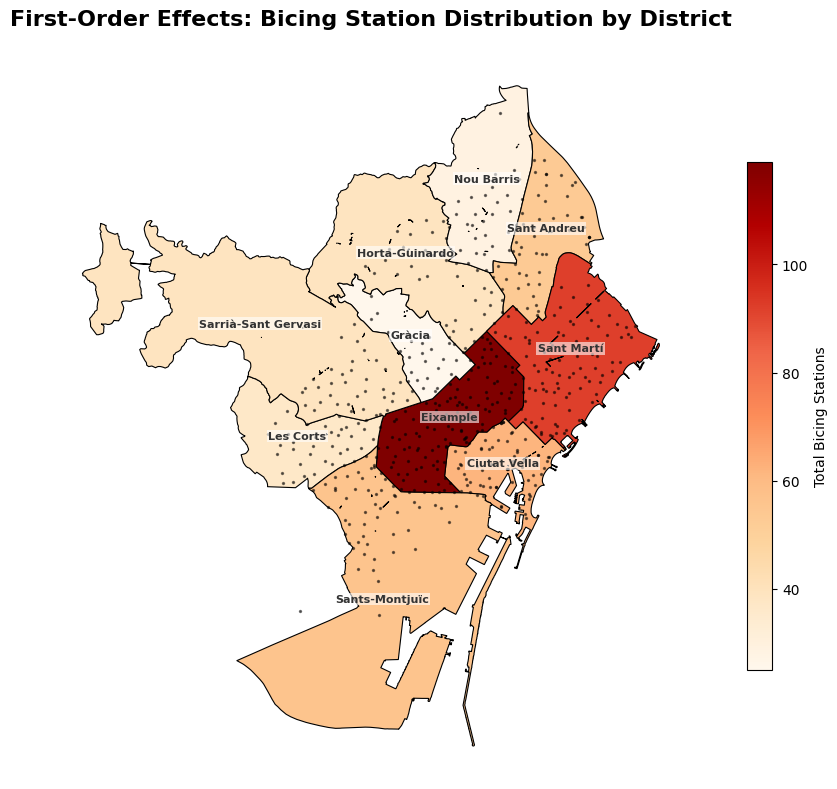

In [ ]:
import matplotlib.pyplot as plt

# ==========================================
# 1. Aggregate the Data
# ==========================================
# Count how many times each district appears in the spatial join
# This gives us the total number of stations per district
district_counts = stations_with_nhood.groupby('nom_districte').size().reset_index(name='station_count')

# Merge this count back into our District polygons GeoDataFrame
# We use a 'left' join so we don't lose a district even if it has 0 stations
districts_heatmap = districts_gdf.merge(district_counts, on='nom_districte', how='left')

# Fill any missing values with 0
districts_heatmap['station_count'] = districts_heatmap['station_count'].fillna(0)

# ==========================================
# 2. Visualize the Choropleth Map
# ==========================================
fig, ax = plt.subplots(1, 1, figsize=(12, 8))

# Plot the map
# 'cmap=OrRd' gives it that classic "Heatmap" look (Orange-Red)
districts_heatmap.plot(
    column='station_count', 
    cmap='OrRd', 
    linewidth=0.8, 
    ax=ax, 
    edgecolor='black', # Black borders for the districts
    legend=True,
    legend_kwds={
        'label': "Total Bicing Stations", 
        'orientation': "vertical",
        'shrink': 0.7 # Makes the legend bar a bit smaller and cleaner
    }
)

# Plot the actual station dots on top as tiny black markers (Optional, but looks great!)
stations_gdf.plot(ax=ax, color='black', markersize=2, alpha=0.5)

# Add titles and clean up the axes
plt.title('First-Order Effects: Bicing Station Distribution by District', fontsize=16, fontweight='bold', pad=20)
ax.axis('off') # Hides the coordinate grid for a cleaner map

# Add District Labels to the map
# This loops through each district, finds its center, and writes the name
for idx, row in districts_heatmap.iterrows():
    ax.annotate(
        text=row['nom_districte'], 
        xy=(row.geometry.centroid.x, row.geometry.centroid.y),
        horizontalalignment='center',
        fontsize=8,
        weight='bold',
        color='#333333',
        # Add a tiny white halo around the text so it's readable over dark red areas
        bbox=dict(facecolor='white', alpha=0.6, edgecolor='none', pad=1)
    )

plt.tight_layout()
plt.show()

# Seond partof the analysis

In [12]:
import os
import sys
import pandas as pd
import geopandas as gpd
import json
from shapely.geometry import shape

# Get the absolute path of the directory one level up (your project root)
# If your notebook is in /project/notebooks/, this points to /project/
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))

# Add it to sys.path so Python can find 'src'
if project_root not in sys.path:
    sys.path.append(project_root)

# Now Python can successfully find the 'src' module
from src.utils.database_connection import DatabaseConnector

database = DatabaseConnector('.env')

In [13]:
import pandas as pd
import numpy as np

# ==========================================
# 1. The MobilityDB Query
# ==========================================
query = """
WITH station_usage_early AS (
    -- 1. Get the average number of bikes between 7:30 and 8:00 AM across ALL days
    SELECT 
        station_id,
        AVG(num_bikes) AS expected_avg_bikes
    FROM station_status_input
    WHERE report_time::time >= '07:30:00'::time 
      AND report_time::time < '08:00:00'::time
    GROUP BY station_id
),
station_usage_late AS (
    -- 2. Get the average number of bikes between 9:30 and 10:00 AM across ALL days
    SELECT 
        station_id,
        AVG(num_bikes) AS expected_avg_bikes
    FROM station_status_input
    WHERE report_time::time >= '09:30:00'::time 
      AND report_time::time < '10:00:00'::time
    GROUP BY station_id
)
SELECT
    st.id AS station_id,
    st.street AS name,
    ST_X(st.geom) AS lon,
    ST_Y(st.geom) AS lat,
    COALESCE(e.expected_avg_bikes, 0) AS expected_avg_bikes_early,
    COALESCE(l.expected_avg_bikes, 0) AS expected_avg_bikes_late,
    -- 3. Calculate the Net Change (Tidal Flow)
    COALESCE(l.expected_avg_bikes, 0) - COALESCE(e.expected_avg_bikes, 0) AS bike_change_morning
FROM stations st
LEFT JOIN station_usage_early e ON st.id = e.station_id
LEFT JOIN station_usage_late l ON st.id = l.station_id;
"""

In [14]:
# ==========================================
# 2. Execute and Load DataFrame
# ==========================================
check_query = """
SELECT 
    MIN(startTimestamp(bikes_history)) as first_data_point, 
    MAX(endTimestamp(bikes_history)) as last_data_point 
FROM station_status_mdb;
"""
print(database.execute_query(check_query, fetch=True))

results = database.execute_query(query, fetch=True)

df_status = pd.DataFrame(results, columns=[
    'station_id', 
    'name', 
    'lon', 
    'lat', 
    'expected_avg_bikes_early', 
    'expected_avg_bikes_late', 
    'bike_change_morning'  # THIS is your "net flow"
])

print(f"Loaded {len(df_status)} stations from MobilityDB!")
print(df_status['bike_change_morning'].head(50))

Database connection established successfully.
[RealDictRow([('first_data_point', datetime.datetime(2024, 12, 30, 18, 2, 59, tzinfo=datetime.timezone.utc)), ('last_data_point', datetime.datetime(2026, 3, 31, 21, 55, 1, tzinfo=datetime.timezone.utc))])]
Loaded 544 stations from MobilityDB!
0     -1.1402381528046422
1     -0.5364064735085406
2     -1.1868646597561416
3     -0.4029771280699498
4      0.1901042601962669
5      0.5420604458986137
6      1.4369668499001849
7      1.5953470164090329
8      1.9668842682140554
9      0.7316314796190263
10     1.4835422547323479
11     1.8673472257940080
12     5.7842155460181211
13     2.7599109445519020
14     2.0757740282324468
15     3.9538241770605632
16     0.3962499649398367
17     0.1363220609213728
18    -1.1454435811853140
19    -1.1332426443777522
20    -0.5108710263123577
21     3.2212857263063417
22     1.1893526738692106
23     1.2391033445241053
24    -0.2836006587303813
25     0.6692428926471480
26    -0.7759859625668449
27    -0.

In [15]:
# ==========================================
# 3. Create the 2 Groups for Ripley's K
# ==========================================
# Because SQL did all the heavy lifting, we skip the Pandas groupings and go straight to sorting!

# Group 1: The Pickups (Stations losing the most bikes)
# Sort by bike_change_morning ascending (most negative first)
pickups_df = df_status.sort_values(by='bike_change_morning', ascending=True).head(50)
coords_pickups = np.column_stack((pickups_df.lon, pickups_df.lat)) 

# Group 2: The Drop-offs (Stations gaining the most bikes)
# Sort by bike_change_morning descending (most positive first)
dropoffs_df = df_status.sort_values(by='bike_change_morning', ascending=False).head(50)
coords_dropoffs = np.column_stack((dropoffs_df.lon, dropoffs_df.lat)) 

print(f"Prepared {len(coords_pickups)} pickup coordinates and {len(coords_dropoffs)} drop-off coordinates for Ripley's K.")

print(coords_pickups[:5])  # Show first 5 pickup coordinates
print(coords_dropoffs[:5])  # Show first 5 drop-off coordinates

Prepared 50 pickup coordinates and 50 drop-off coordinates for Ripley's K.
[[ 2.1809764 41.4110754]
 [ 2.1671611 41.3806411]
 [ 2.1592394 41.3751852]
 [ 2.1844769 41.4172922]
 [ 2.1594741 41.3812504]]
[[ 2.1999572 41.3896642]
 [ 2.2037136 41.3919877]
 [ 2.1904003 41.3902194]
 [ 2.195551  41.388143 ]
 [ 2.195073  41.388507 ]]


In [16]:
print("--- Morning Pickups (Downs) ---")
# 1. Create the GeoDataFrame and project to meters (EPSG:25831)
stationspickups = gpd.GeoDataFrame(
    pickups_df, 
    geometry=gpd.points_from_xy(pickups_df.lon, pickups_df.lat), 
    crs="EPSG:4326"
).to_crs("EPSG:25831")

# 2. Pass the GeoDataFrame (stationspickups) to the function
chart_pickups = analyze_and_plot_area(stationspickups, "Barcelona (True Polygon)", max_distance=1000)

# 3. Override the title so it looks great in your presentation
chart_pickups = chart_pickups.properties(title="Ripley's L: Morning Pickups (Downs)")
chart_pickups.display()


print("\n--- Morning Drop-offs (Ups) ---")
# 1. Create the GeoDataFrame and project to meters (EPSG:25831)
stationsdropoffs = gpd.GeoDataFrame(
    dropoffs_df, 
    geometry=gpd.points_from_xy(dropoffs_df.lon, dropoffs_df.lat), 
    crs="EPSG:4326"
).to_crs("EPSG:25831")

# 2. Pass the GeoDataFrame (stationsdropoffs) to the function
chart_dropoffs = analyze_and_plot_area(stationsdropoffs, "Barcelona (True Polygon)", max_distance=1000)

# 3. Override the title
chart_dropoffs = chart_dropoffs.properties(title="Ripley's L: Morning Drop-offs (Ups)")
chart_dropoffs.display()

--- Morning Pickups (Downs) ---
Computing Barcelona (True Polygon): 50 stations inside 101.69 km²


alt.LayerChart(...)


--- Morning Drop-offs (Ups) ---
Computing Barcelona (True Polygon): 50 stations inside 101.69 km²


alt.LayerChart(...)

In [21]:
import folium
from folium.plugins import FeatureGroupSubGroup

# 1. Initialize the map centered on Barcelona
# We use CartoDB dark_matter tiles to match your dashboard presentation theme
m = folium.Map(
    location=[41.3874, 2.1686], # Coordinates for central Barcelona
    zoom_start=13, 
    tiles="CartoDB positron"
)

# 2. Create map layers (so you can toggle them on/off live during your presentation!)
fg_pickups = folium.FeatureGroup(name="Morning Pickups (Downs: Net Loss)")
fg_dropoffs = folium.FeatureGroup(name="Morning Drop-offs (Ups: Net Gain)")

# 3. Plot the Top 50 Pickups (Blue Circles)
for idx, row in pickups_df.iterrows():
    folium.CircleMarker(
        location=[row['lat'], row['lon']],
        radius=6,
        color="#38bdf8",       # Glowing Neon Blue
        fill=True,
        fill_color="#38bdf8",
        fill_opacity=0.7,
        popup=folium.Popup(
            f"<b>Station:</b> {row['name']}<br>"
            f"<b>Net Change:</b> <span style='color:#38bdf8;'>{round(row['bike_change_morning'], 1)} bikes</span>", 
            max_width=300
        )
    ).add_to(fg_pickups)

# 4. Plot the Top 50 Drop-offs (Red Circles)
for idx, row in dropoffs_df.iterrows():
    folium.CircleMarker(
        location=[row['lat'], row['lon']],
        radius=6,
        color="#ef4444",       # Glowing Neon Red
        fill=True,
        fill_color="#ef4444",
        fill_opacity=0.7,
        popup=folium.Popup(
            f"<b>Station:</b> {row['name']}<br>"
            f"<b>Net Change:</b> <span style='color:#ef4444;'>+{round(row['bike_change_morning'], 1)} bikes</span>", 
            max_width=300
        )
    ).add_to(fg_dropoffs)

# 5. Add layers and a control panel to the map
fg_pickups.add_to(m)
fg_dropoffs.add_to(m)
folium.LayerControl(collapsed=False).add_to(m)

# Display the map directly in your Jupyter Notebook
m

#Save as HTML (optional, but great for sharing or embedding in a presentation)
m.save('../reports/figures/bicing_morning_flows_map.html')
